<a href="https://colab.research.google.com/github/VictorHugoTesti/-am-t4-s1a2026/blob/main/MultiNeuralCredit0609.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Random Forest | Digest Pickle [Fase 1 - credit_data]

## Importar dados Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bibliotecas Python

In [2]:
!pip -q install plotly
!pip -q install yellowbrick

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_credit

In [4]:
import pickle

In [5]:
with open('/content/drive/MyDrive/Aprendizagem de Maquina/credit.pkt', 'rb') as f:
   X_credit_treinamento, Y_credit_treinamento, X_credit_teste, Y_credit_teste = pickle.load(f)

In [6]:
X_credit_treinamento.shape, Y_credit_teste.shape

((1700, 3), (300,))

In [7]:
X_credit_teste.shape, Y_credit_teste.shape

((300, 3), (300,))

In [8]:
from sklearn.ensemble import RandomForestClassifier

In [9]:
from warnings import warn
random_credit = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
random_credit.fit(X_credit_treinamento, Y_credit_treinamento)
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None, criterion="entropy", max_depth='auto',
                        min_impurity_decrease=0.0, min_samples_split=None,
                        min_samples_leaf=1, min_weight_fraction_leaf=0.0, n_estimators=10,
                        n_jobs=None, oob_score=False, random_state=0, verbose=0, warm_start=False)


RandomForestClassifier(criterion='entropy', max_depth='auto',
                       min_samples_split=None, n_estimators=10, random_state=0)

## Criando Base Provisória

In [10]:
previsoes_arvore = random_credit.predict(X_credit_teste)

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [12]:
accuracy_score(Y_credit_teste, previsoes_arvore)

0.9733333333333334

In [13]:
confusion_matrix(Y_credit_teste, previsoes_arvore)

array([[257,   3],
       [  5,  35]])

In [14]:
print(classification_report(Y_credit_teste, previsoes_arvore))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       260
           1       0.92      0.88      0.90        40

    accuracy                           0.97       300
   macro avg       0.95      0.93      0.94       300
weighted avg       0.97      0.97      0.97       300



In [15]:
from yellowbrick.classifier import ConfusionMatrix

0.9733333333333334

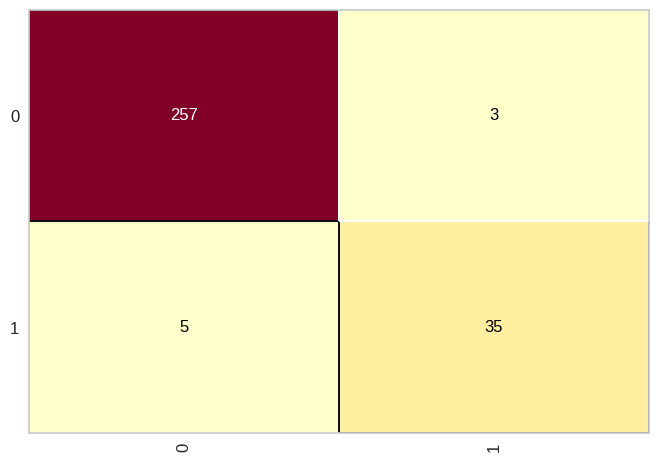

In [16]:
cm_credit = ConfusionMatrix(random_credit)
cm_credit.fit(X_credit_treinamento, Y_credit_treinamento)
cm_credit.score(X_credit_teste, Y_credit_teste)

# Pipeline SVM | Digest [Fase 1 - credit_base]

In [39]:
from sklearn.svm import SVC

In [40]:
svm_credit = SVC(kernel='rbf', random_state=1, C=2.0)
svm_credit.fit(X_credit_treinamento, Y_credit_treinamento)

SVC(C=2.0, random_state=1)

In [41]:
SVC(C=2.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=1, probability=False, random_state=1, shrinking=True, tol=0.001,
    verbose=False)

SVC(C=2.0, max_iter=1, random_state=1)

In [42]:
svc_previsores = svm_credit.predict(X_credit_teste)
svc_previsores

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [43]:
accuracy_score(Y_credit_teste, svc_previsores)

0.9933333333333333

0.9933333333333333

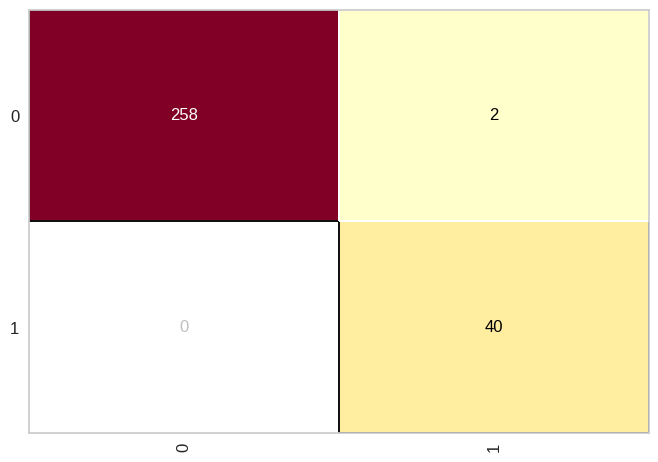

In [44]:
svm_cm = ConfusionMatrix(svm_credit)
svm_cm.fit(X_credit_treinamento, Y_credit_treinamento)
svm_cm.score(X_credit_teste, Y_credit_teste)

In [45]:
print(classification_report(Y_credit_teste, svc_previsores))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       260
           1       0.95      1.00      0.98        40

    accuracy                           0.99       300
   macro avg       0.98      1.00      0.99       300
weighted avg       0.99      0.99      0.99       300

